# Option-Portfolio Risk: Greeks and Stress Testing

This notebook covers the portfolio-*risk* half of the toolkit. Starting from a
fixed six-option book, it computes the portfolio Greeks from the GARCH
volatility forecast, tracks them through time, and stress-tests the book under
price and volatility shocks -- comparing a linear (delta-normal) view, a
quadratic (delta-gamma) view, and full revaluation.

**Conventions:** volatility annualised on 252 days; strikes fixed at inception
(`K = moneyness x spot`); Greek units are vega per 1 vol point, theta per
trading day.

> As in the companion notebook, fitting the rolling GARCH takes a couple of
> minutes.

In [9]:
import dataclasses
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from garch_risk.config import DEFAULT_PORTFOLIO, RISK_FREE_RATE
from garch_risk.data import download_prices, align_calendar, log_returns
from garch_risk.volatility import rolling_garch_forecasts
from garch_risk.var_es import rolling_var_es
from garch_risk.greeks import portfolio_greeks_snapshot, daily_portfolio_greeks
from garch_risk.risk import portfolio_value, pnl_curve, stress_grid
from garch_risk import plots

WINDOW, REFIT = 365, 21

## 1. The option book

Six positions across the three underlyings -- a mix of calls and puts, long and
short, at different strikes and maturities. A negative quantity is a short
position. `moneyness` is the strike as a multiple of the spot at inception.

In [10]:
pd.DataFrame([dataclasses.asdict(p) for p in DEFAULT_PORTFOLIO]).set_index("id")

,underlying,option_type,moneyness,days_to_expiry,quantity
id,,,,,
O1,S&P500,call,1.00,30,5
O2,S&P500,put,0.95,60,2
O3,NASDAQ,put,1.00,45,-3
O4,NASDAQ,call,1.10,90,4
O5,BTC-USD,call,0.95,20,1
O6,BTC-USD,put,0.90,30,2


## 2. Market snapshot and GARCH volatility

Prices are downloaded and the rolling GJR-GARCH volatility (and fitted Student-t
degrees of freedom) is fit per asset. The **snapshot** is the most recent date
for which every asset has a forecast; that day's spot and GARCH volatility
define the state the book is evaluated in.

In [11]:
prices = align_calendar(download_prices(lookback_years=10), strip_weekends=True)
rets = log_returns(prices)

fits = {a: rolling_garch_forecasts(rets[a], window=WINDOW, refit_every=REFIT)
        for a in prices.columns}
sigma = {a: fits[a]["sigma"] for a in prices.columns}
nu = {a: fits[a]["nu"] for a in prices.columns}

snap_date = min(sigma[a].index.max() for a in prices.columns)
base_spots = {a: float(prices[a].loc[snap_date]) for a in prices.columns}
base_sigmas = {a: float(sigma[a].loc[snap_date]) for a in prices.columns}

pd.DataFrame({a: {"spot": base_spots[a],
                  "ann. vol %": round(base_sigmas[a]*np.sqrt(252)*100, 1)}
              for a in prices.columns}).T

,spot,ann. vol %
S&P500,7500.580078,17.6
NASDAQ,26517.929688,26.4
BTC-USD,62896.472656,43.4


## 3. Portfolio Greeks at the snapshot

Greeks are computed per position from Black-Scholes with the GARCH volatility,
quantity-weighted, and aggregated by underlying. Strikes are pinned at the
snapshot spot.

In [12]:
snap = portfolio_greeks_snapshot(DEFAULT_PORTFOLIO, base_spots, base_sigmas, RISK_FREE_RATE)
value = portfolio_value(DEFAULT_PORTFOLIO, base_spots, base_sigmas, RISK_FREE_RATE,
                        {p.id: p.moneyness*base_spots[p.underlying] for p in DEFAULT_PORTFOLIO})
print(f"Portfolio value at snapshot: {value:,.2f}")
snap.round(4)

Portfolio value at snapshot: 8,238.79


,Delta,Gamma,Vega,Theta
Asset,,,,
S&P500,2.1528,0.0054,74.4043,-19.6210
NASDAQ,2.6570,-0.0001,91.7320,0.5249
BTC-USD,0.2624,0.0001,188.8540,-159.9108
Total,5.0722,0.0054,354.9903,-179.0069


### Reading the Greeks

Expect the book to be **net long delta** (directional exposure), **long vega**
(it benefits from rising volatility), and **negative theta** (long options bleed
time value). Watch the per-asset structure too: a sub-book combining short puts
with long calls on the same underlying can come out close to **gamma- and
theta-neutral**, because the short options' negative gamma and positive theta
offset the long options' -- a nice illustration that aggregate Greeks hide
offsetting structure underneath.

## 4. Greeks through time

Holding the strikes fixed at their day-0 values, the Greeks are rolled forward
over the most recent 60 trading days. This is an *illustration of decay*: as
each option approaches and passes its expiry it stops contributing, so gamma,
vega and theta collapse toward zero -- a visual of how a book's risk profile
rolls off over time. (It is not a live position; it shows how a book struck 60
days ago would have decayed.)

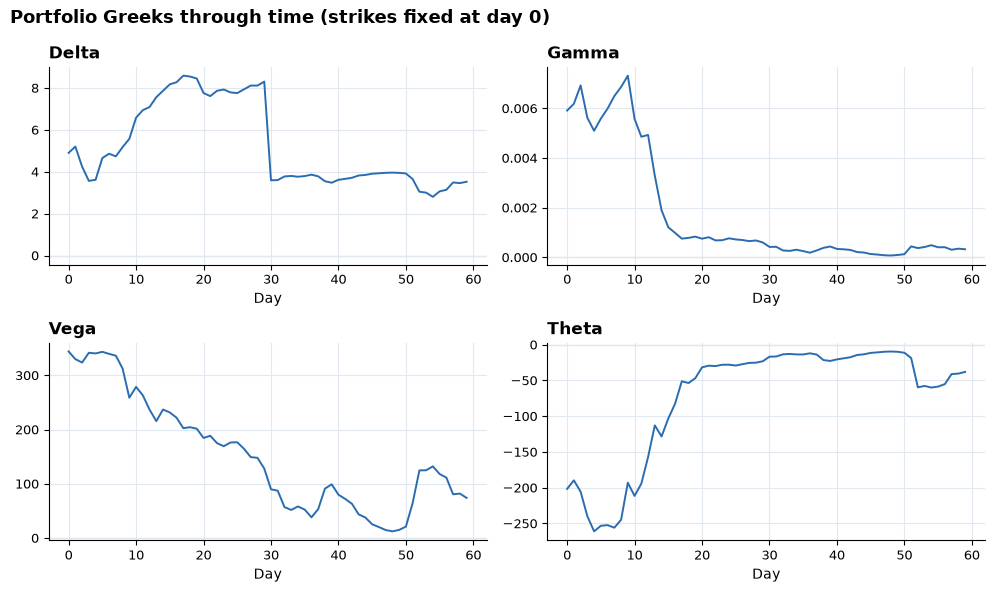

In [13]:
n = 60
spot_paths = {a: prices[a].loc[sigma[a].index].to_numpy()[-n:] for a in prices.columns}
sigma_paths = {a: sigma[a].to_numpy()[-n:] for a in prices.columns}
greeks_ts = daily_portfolio_greeks(DEFAULT_PORTFOLIO, spot_paths, sigma_paths, RISK_FREE_RATE)

fig = plots.plot_greeks_evolution(greeks_ts, asset="Total",
                                  title="Portfolio Greeks through time (strikes fixed at day 0)")
plt.show()

## 5. Stress testing: linear vs quadratic vs full revaluation

A common percentage shock is applied to all underlyings (volatility held), and
the book's P&L is computed three ways: the linear delta-normal estimate, the
quadratic delta-gamma estimate, and a full reprice. The gap between them is the
convexity a delta-only risk view misses.

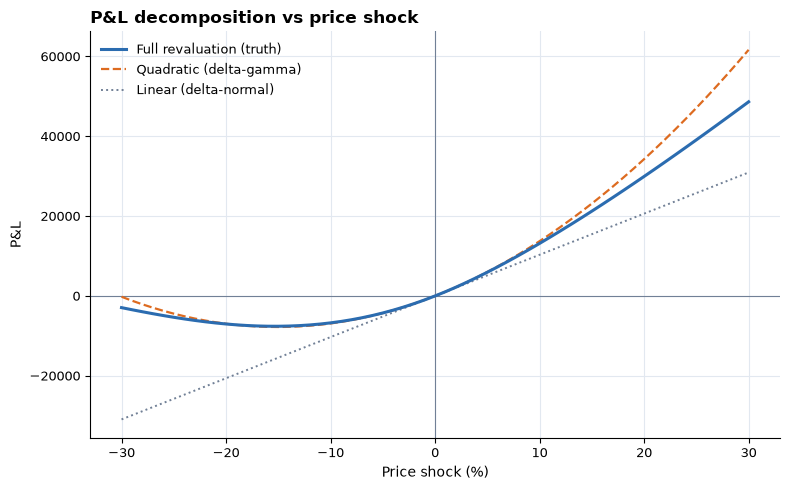

In [14]:
curve = pnl_curve(DEFAULT_PORTFOLIO, base_spots, base_sigmas, RISK_FREE_RATE,
                  shocks=np.linspace(-0.30, 0.30, 61))
fig = plots.plot_pnl_curve(curve, title="P&L decomposition vs price shock")
plt.show()

### Reading the P&L curve

For small moves the three lines coincide. As the shock grows the **linear**
estimate peels away first -- for a long-gamma book it *overstates* losses and
*understates* gains, because it ignores the curvature of the payoff. The
**quadratic** correction tracks the truth much further out.

The important caveat: at large shocks the **quadratic also fails**, overshooting
in the opposite direction -- a second-order Taylor expansion is still only local.
Only full revaluation is reliable in the deep tail. That is precisely the
limitation of a delta-gamma VaR system, made visible.

## 6. Joint price / volatility stress grid

Full revaluation across a grid of simultaneous price and volatility shocks -- the
stress surface a risk desk actually looks at.

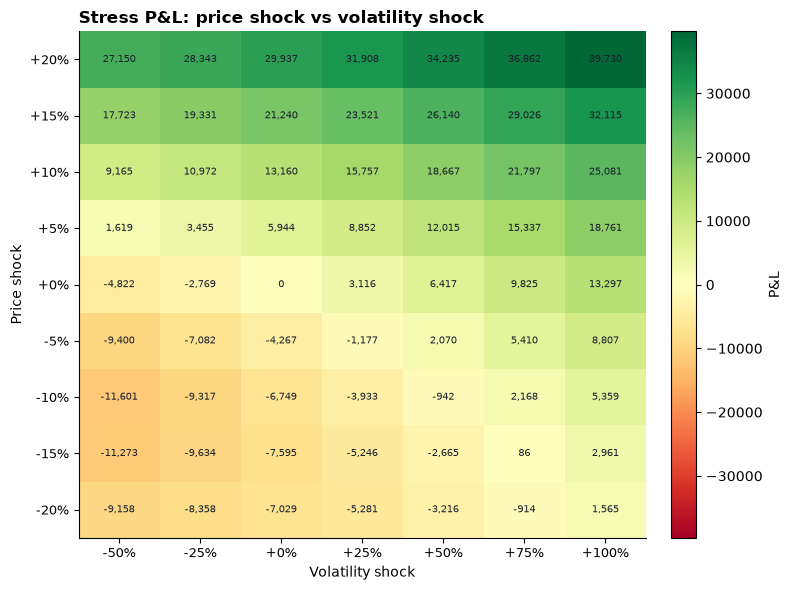

In [15]:
grid = stress_grid(DEFAULT_PORTFOLIO, base_spots, base_sigmas, RISK_FREE_RATE,
                   price_shocks=np.linspace(-0.20, 0.20, 9),
                   vol_shocks=np.linspace(-0.50, 1.00, 7))
fig = plots.plot_stress_grid(grid, title="Stress P&L: price shock vs volatility shock")
plt.show()

### Reading the stress grid

The most instructive cell is usually the **bottom-right corner**: a large price
*drop* combined with a large volatility *spike*. For a long-vega, long-gamma
book that scenario can produce a **positive** P&L -- the volatility gain and the
gamma convexity together outweigh the directional loss. That is the signature of
a book that is long volatility: it can profit in a crash *provided* volatility
spikes with it. Reading the grid left-to-right (rising vol) and bottom-to-top
(rising price) shows how the two risks interact rather than add.

## 7. Risk dashboard

A single combined view. The top row is market risk for a representative asset
(its GARCH volatility and 95% VaR backtest, using the same fitted-dof method as
the companion notebook); the bottom row is the portfolio's own P&L decomposition
and stress surface.

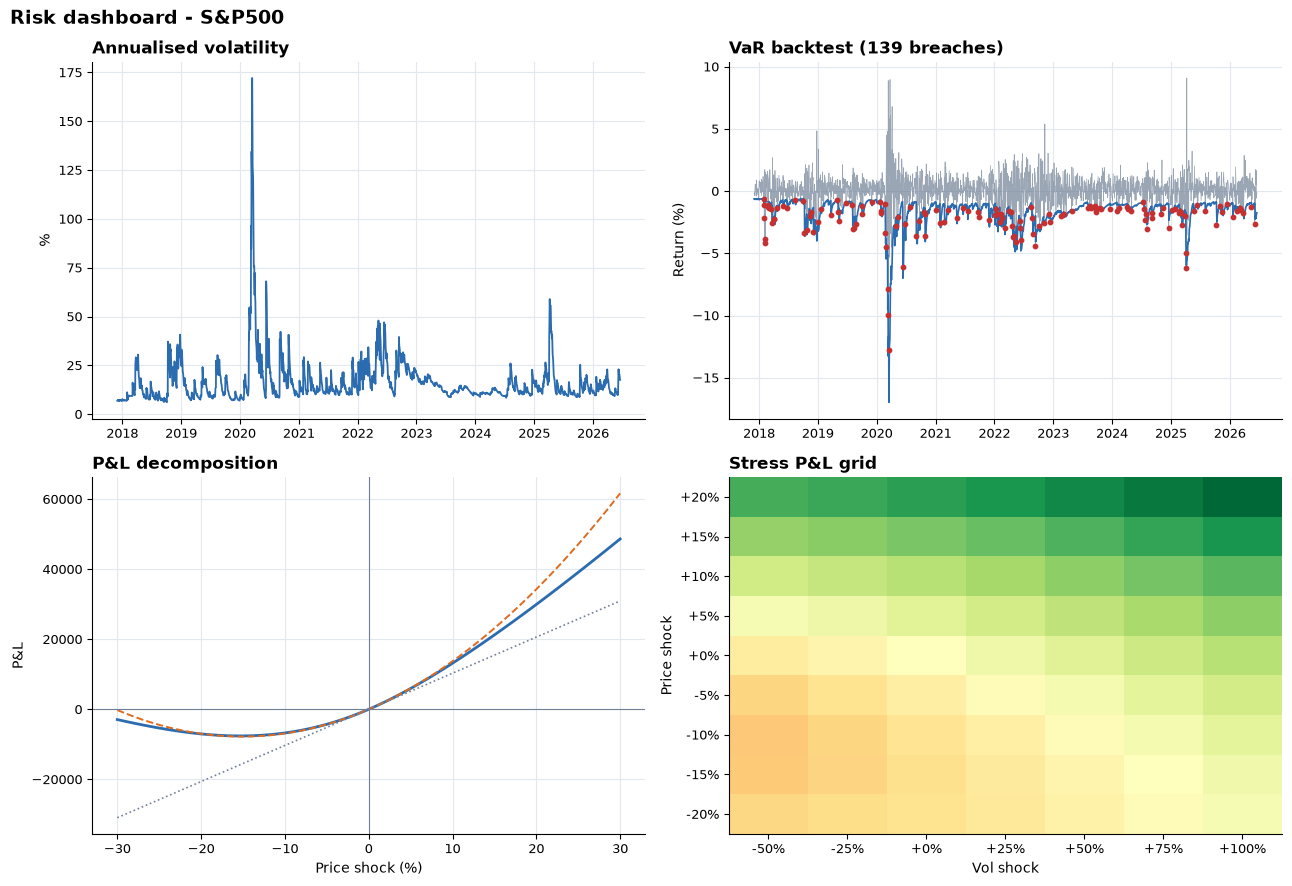

In [16]:
rep = "S&P500"
rep_var = rolling_var_es(sigma[rep], alpha=0.05, dist="t",
                         dof=nu[rep], n_sims=100_000)["VaR"]

fig = plots.plot_risk_dashboard(sigma[rep], rets[rep], rep_var, curve, grid, asset=rep)
plt.show()

## Summary

The toolkit composes end to end: a GARCH volatility forecast feeds option
Greeks and a full stress framework for a realistic multi-asset option book. The
P&L decomposition makes the limits of linear and quadratic risk approximations
visible, and the stress grid shows how price and volatility risk interact for a
long-volatility book. Volatility-model calibration and the disclosed
limitations are covered in the companion notebook.